题目描述
请你构造一个用于多分类任务的全连接神经网络。数据集由 2000 个样本构成，每个样本有 15 个特征，目标类别共有 5 类。请使用 PyTorch 完成如下任务：

数据生成

生成 2000 个样本，每个样本 15 个特征，样本特征从标准正态分布（均值 0，方差 1）采样。

随机生成一个权重矩阵
𝑇
T（尺寸为 15×5）和偏置向量
𝑏
b（尺寸为 5），然后对每个样本计算

logits
=
tanh
⁡
(
𝑥
⋅
𝑇
+
𝑏
)
logits=tanh(x⋅T+b)

对每个样本，从
logits
logits 中取最大值所在的索引作为类别标签。例如，如果某样本的
logits
=
[
0.2
,
−
0.5
,
0.8
,
0.1
,
−
0.2
]
logits=[0.2,−0.5,0.8,0.1,−0.2]，则其类别标签为 2。

将数据集随机划分为训练集（80%）和验证集（20%）。

网络结构设计
构造一个全连接神经网络，要求结构如下：

输入层：15 个神经元

隐藏层 1：40 个神经元，使用 ReLU 激活函数，并在其后添加 Dropout 层（丢弃率 0.3）

隐藏层 2：25 个神经元，使用 Tanh 激活函数

隐藏层 3：15 个神经元，使用 ReLU 激活函数

输出层：5 个神经元，直接输出 logits（注意：在多分类任务中，通常不在输出层使用激活函数，因为 nn.CrossEntropyLoss 内部会计算 softmax）。

训练配置

损失函数：nn.CrossEntropyLoss()

优化器：Adam，学习率设置为 0.001

训练 epoch 数：1000

在每个 epoch 内，记录训练集和验证集上的损失，并绘制损失曲线。

在训练结束后，计算并输出验证集的分类准确率，并使用混淆矩阵可视化模型在验证集上的分类情况。

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class SimpleNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(15, 40)
    self.dropout1 = nn.Dropout(p=0.3)

    self.layer2 = nn.Linear(40, 25)
    self.layer3 = nn.Linear(25, 15)

    self.output = nn.Linear(15, 5)

  def forward(self, x):
    x = torch.relu(self.layer1(x))
    x = self.dropout1(x)

    x = torch.tanh(self.layer2(x))
    x = torch.relu(self.layer3(x))
    x = self.output(x)
    return x

epoch: 1 train_loss: 1.6005, val_loss: 1.6011
epoch: 101 train_loss: 0.8506, val_loss: 0.8002
epoch: 201 train_loss: 0.3601, val_loss: 0.2941
epoch: 301 train_loss: 0.2559, val_loss: 0.1945
epoch: 401 train_loss: 0.2015, val_loss: 0.1688
epoch: 501 train_loss: 0.1836, val_loss: 0.1490
epoch: 601 train_loss: 0.1738, val_loss: 0.1462
epoch: 701 train_loss: 0.1565, val_loss: 0.1417
epoch: 801 train_loss: 0.1294, val_loss: 0.1425
epoch: 901 train_loss: 0.1010, val_loss: 0.1456
y_pred_val softmax: [[0.   0.1  0.   0.   0.9 ]
 [1.   0.   0.   0.   0.  ]
 [0.   0.   0.   1.   0.  ]
 ...
 [1.   0.   0.   0.   0.  ]
 [0.   0.55 0.17 0.22 0.06]
 [0.   0.   0.   0.   1.  ]]
y_true softmax: [[0.023 0.297 0.007 0.002 0.672]
 [0.971 0.029 0.001 0.    0.   ]
 [0.001 0.001 0.012 0.986 0.   ]
 ...
 [0.757 0.218 0.006 0.016 0.003]
 [0.    0.257 0.348 0.276 0.119]
 [0.    0.    0.    0.    1.   ]]


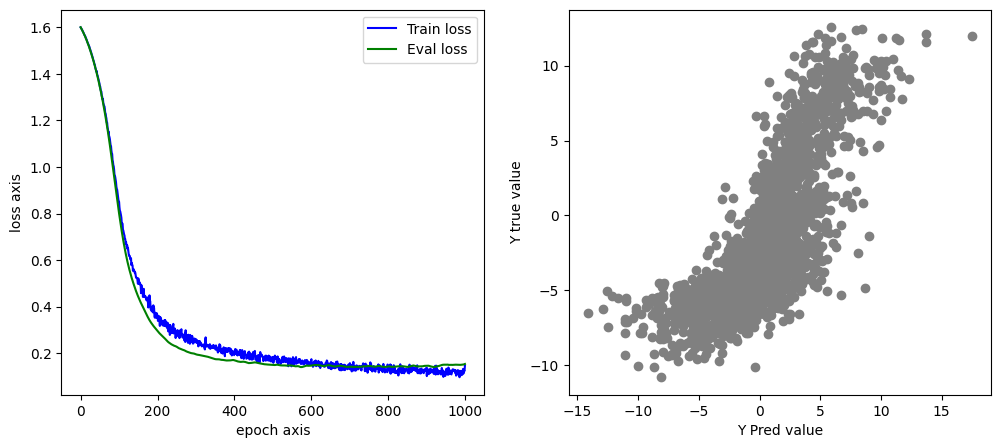

In [73]:
#初始化参数

sample_num = 2000
input_num = 15
output_num = 5

x = torch.randn(sample_num, input_num).to(device)
t = torch.randn(input_num, output_num).to(device)

b = torch.randn(output_num).to(device).to(device)

logits = torch.matmul(x, t) + b

y = torch.argmax(logits, dim=1).to(device)

model = SimpleNN().to(device)

train_size = int(0.8*sample_num)
x_train = x[:train_size].to(device)
y_train = y[:train_size].to(device)

x_val = x[train_size:].to(device)
y_val = y[train_size:].to(device)

train_losses = []
val_losses = []

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 1000

for epoch in range(epochs):
  model.train()
  y_pred_train = model(x_train)

  train_loss = criterion(y_pred_train, y_train)
  train_losses.append(train_loss.item())

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model.eval()
  with torch.no_grad():
    y_pred_val = model(x_val)

    val_loss = criterion(y_pred_val, y_val)
    val_losses.append(val_loss.item())

  if epoch%100==0:
    print(f"epoch: {epoch + 1}",
      f"train_loss: {train_loss.item():.4f}, val_loss: {val_loss.item():.4f}",
    )

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_losses, label="Train loss", color="blue")
plt.plot(range(epochs), val_losses, label="Eval loss", color="green")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")
plt.legend()

with torch.no_grad():
  y_pred_val_np = model(x_val).cpu().numpy()
  #y_val_np = y_val.cpu().numpy()
  y_val_np = logits[train_size:].cpu().numpy()
  print(f"y_pred_val softmax: {torch.softmax(y_pred_val, dim=1).numpy().round(2)}")
  print(f"y_true softmax: {torch.softmax(logits[train_size:], dim=1).numpy().round(3)}")

plt.subplot(1, 2, 2)
plt.scatter(y_val_np, y_pred_val_np, color= "gray")
plt.xlabel("Y Pred value")
plt.ylabel("Y true value")
plt.show()